## Preliminares

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.config import data_folder
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4489 non-null   datetime64[ns]
 1   Open                    4489 non-null   float64       
 2   Close                   4489 non-null   float64       
 3   Dividends               4489 non-null   float64       
 4   Ticker                  4489 non-null   object        
 5   Sector                  4489 non-null   object        
 6   DateAdded               4489 non-null   object        
 7   TotalRevenue            4489 non-null   float64       
 8   GrossProfit             4243 non-null   float64       
 9   OperatingIncome         4489 non-null   float64       
 10  NetIncome               4489 non-null   float64       
 11  EBITDA                  4489 non-null   float64       
 12  BasicAverageShares      4485 non-null   float64 

In [3]:
# Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres)
df = transformar_flujos_a_ttm(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4489 non-null   datetime64[ns]
 1   Open                    4489 non-null   float64       
 2   Close                   4489 non-null   float64       
 3   Dividends               4489 non-null   float64       
 4   Ticker                  4489 non-null   object        
 5   Sector                  4489 non-null   object        
 6   DateAdded               4489 non-null   object        
 7   CashAndCashEquivalents  4482 non-null   float64       
 8   CurrentDebt             3625 non-null   float64       
 9   LongTermDebt            4300 non-null   float64       
 10  TotalDebt               3895 non-null   float64       
 11  StockholdersEquity      4483 non-null   float64       
 12  TotalAssets             4485 non-null   float64 

In [4]:
# Valores missing
df.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

CurrentDebt               0.192470
TotalDebt                 0.132323
GrossProfit_TTM           0.126754
CapitalExpenditure_TTM    0.086211
FreeCashFlow_TTM          0.083760
FinancingCashFlow_TTM     0.079973
OperatingCashFlow_TTM     0.079973
InvestingCashFlow_TTM     0.079973
BasicAverageShares_TTM    0.079528
OperatingIncome_TTM       0.079082
NetIncome_TTM             0.079082
TotalRevenue_TTM          0.079082
EBITDA_TTM                0.079082
LongTermDebt              0.042103
CashAndCashEquivalents    0.001559
StockholdersEquity        0.001337
TotalAssets               0.000891
CurrentLiabilities        0.000891
CurrentAssets             0.000891
DateAdded                 0.000000
Ticker                    0.000000
Dividends                 0.000000
Close                     0.000000
Open                      0.000000
Date                      0.000000
Sector                    0.000000
dtype: float64

In [5]:
# Se imputan parte de los NaNs en variables de Deuda antes de calcular métricas, 
# mediante las relaciones contables entre ellas.
df_debt_imputed = imputar_deuda(df)
df_debt_imputed.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

CurrentDebt               0.142348
TotalDebt                 0.132323
GrossProfit_TTM           0.126754
CapitalExpenditure_TTM    0.086211
FreeCashFlow_TTM          0.083760
FinancingCashFlow_TTM     0.079973
OperatingCashFlow_TTM     0.079973
InvestingCashFlow_TTM     0.079973
BasicAverageShares_TTM    0.079528
OperatingIncome_TTM       0.079082
NetIncome_TTM             0.079082
TotalRevenue_TTM          0.079082
EBITDA_TTM                0.079082
LongTermDebt              0.038761
CashAndCashEquivalents    0.001559
StockholdersEquity        0.001337
TotalAssets               0.000891
CurrentLiabilities        0.000891
CurrentAssets             0.000891
DateAdded                 0.000000
Ticker                    0.000000
Dividends                 0.000000
Close                     0.000000
Open                      0.000000
Date                      0.000000
Sector                    0.000000
dtype: float64

In [6]:
# Calcular métricas
df_with_metrics, crecimiento_cols = calcular_metricas(df_debt_imputed)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4489 non-null   datetime64[ns]
 1   Open                    4489 non-null   float64       
 2   Close                   4489 non-null   float64       
 3   Dividends               4489 non-null   float64       
 4   Ticker                  4489 non-null   object        
 5   Sector                  4489 non-null   object        
 6   DateAdded               4489 non-null   object        
 7   CashAndCashEquivalents  4482 non-null   float64       
 8   CurrentDebt             3850 non-null   float64       
 9   LongTermDebt            4315 non-null   float64       
 10  TotalDebt               3895 non-null   float64       
 11  StockholdersEquity      4483 non-null   float64       
 12  TotalAssets             4485 non-null   float64 

In [7]:
# Se aplica imputación transversal para las columnas de crecimiento
df_with_metrics = imputar_transversal(df_with_metrics, crecimiento_cols)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4489 non-null   datetime64[ns]
 1   Open                    4489 non-null   float64       
 2   Close                   4489 non-null   float64       
 3   Dividends               4489 non-null   float64       
 4   Ticker                  4489 non-null   object        
 5   Sector                  4489 non-null   object        
 6   DateAdded               4489 non-null   object        
 7   CashAndCashEquivalents  4482 non-null   float64       
 8   CurrentDebt             3850 non-null   float64       
 9   LongTermDebt            4315 non-null   float64       
 10  TotalDebt               3895 non-null   float64       
 11  StockholdersEquity      4483 non-null   float64       
 12  TotalAssets             4485 non-null   float64 

In [8]:
# Calcular los retornos trimestrales, varianza del activo y covarianza con el mercado para cada ticker
# Se abre el fichero de precios del Índice del Mercado
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")
df_with_features = calcular_retornos(df_with_metrics, df_index)
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4489 non-null   datetime64[ns]
 1   Open                    4489 non-null   float64       
 2   Close                   4489 non-null   float64       
 3   Dividends               4489 non-null   float64       
 4   Ticker                  4489 non-null   object        
 5   Sector                  4489 non-null   object        
 6   DateAdded               4489 non-null   object        
 7   CashAndCashEquivalents  4482 non-null   float64       
 8   CurrentDebt             3850 non-null   float64       
 9   LongTermDebt            4315 non-null   float64       
 10  TotalDebt               3895 non-null   float64       
 11  StockholdersEquity      4483 non-null   float64       
 12  TotalAssets             4485 non-null   float64 

## Missing Values

In [9]:
# Incidencia de missings en columnas numéricas
df_cont = df_with_features.select_dtypes(include='number')
df_cont.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

QuarterlyReturn           0.169526
QuarterlyVariance         0.168189
MarketCovariance          0.168189
CurrentDebt               0.142348
TotalDebt                 0.132323
GrossProfit_TTM           0.126754
CapitalExpenditure_TTM    0.086211
CapExToRevenue            0.086211
FreeCashFlow_TTM          0.083760
FcfToEbitda               0.083760
PriceToBook               0.080419
NetDebtToEbitda           0.080196
InvestingCashFlow_TTM     0.079973
OperatingCashFlow_TTM     0.079973
FinancingCashFlow_TTM     0.079973
ReturnOnEquity            0.079973
TrailingPE                0.079528
ReturnOnAssets            0.079528
BasicAverageShares_TTM    0.079528
EnterpriseValue           0.079528
MarketCap                 0.079528
EnterpriseToEbitda        0.079528
EBITDA_TTM                0.079082
OperatingMargins          0.079082
NetIncome_TTM             0.079082
TotalRevenue_TTM          0.079082
OperatingIncome_TTM       0.079082
ProfitMargins             0.079082
LongTermDebt        

In [10]:
# Incidencia de missings en columnas no numéricas
df_non_numeric = df_with_features.select_dtypes(exclude='number')
df_non_numeric.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Date         0.0
Ticker       0.0
Sector       0.0
DateAdded    0.0
dtype: float64

In [11]:
# Comprobar valores infinitos antes de imputación multivariable
print(np.isinf(df_cont).sum())

Open                      0
Close                     0
Dividends                 0
CashAndCashEquivalents    0
CurrentDebt               0
LongTermDebt              0
TotalDebt                 0
StockholdersEquity        0
TotalAssets               0
CurrentAssets             0
CurrentLiabilities        0
TotalRevenue_TTM          0
GrossProfit_TTM           0
OperatingIncome_TTM       0
NetIncome_TTM             0
EBITDA_TTM                0
BasicAverageShares_TTM    0
OperatingCashFlow_TTM     0
InvestingCashFlow_TTM     0
FinancingCashFlow_TTM     0
FreeCashFlow_TTM          0
CapitalExpenditure_TTM    0
MarketCap                 0
EnterpriseValue           0
TrailingPE                0
EnterpriseToEbitda        0
PriceToBook               0
OperatingMargins          0
ProfitMargins             0
ReturnOnEquity            0
ReturnOnAssets            0
DebtToEquity              0
CurrentRatio              0
Revenue_YoY               0
Revenue_QoQ               0
Ebitda_YoY          

In [12]:
# NaN Restantes: Imputación multivariable con IterativeImputer sobre numéricas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Open                    4489 non-null   float64
 1   Close                   4489 non-null   float64
 2   Dividends               4489 non-null   float64
 3   CashAndCashEquivalents  4489 non-null   float64
 4   CurrentDebt             4489 non-null   float64
 5   LongTermDebt            4489 non-null   float64
 6   TotalDebt               4489 non-null   float64
 7   StockholdersEquity      4489 non-null   float64
 8   TotalAssets             4489 non-null   float64
 9   CurrentAssets           4489 non-null   float64
 10  CurrentLiabilities      4489 non-null   float64
 11  TotalRevenue_TTM        4489 non-null   float64
 12  GrossProfit_TTM         4489 non-null   float64
 13  OperatingIncome_TTM     4489 non-null   float64
 14  NetIncome_TTM           4489 non-null   

In [13]:
# Se vuelven a unir las columnas numéricas y no numéricas
df_imputed = pd.concat([df_cont_imputed, df_non_numeric], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Open                    4489 non-null   float64       
 1   Close                   4489 non-null   float64       
 2   Dividends               4489 non-null   float64       
 3   CashAndCashEquivalents  4489 non-null   float64       
 4   CurrentDebt             4489 non-null   float64       
 5   LongTermDebt            4489 non-null   float64       
 6   TotalDebt               4489 non-null   float64       
 7   StockholdersEquity      4489 non-null   float64       
 8   TotalAssets             4489 non-null   float64       
 9   CurrentAssets           4489 non-null   float64       
 10  CurrentLiabilities      4489 non-null   float64       
 11  TotalRevenue_TTM        4489 non-null   float64       
 12  GrossProfit_TTM         4489 non-null   float64 

## Transformaciones

In [14]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)

In [15]:
# Se expresan columnas monetarias en billions
cols_financieras = obtener_cols_financieras()
cols_monetarias = cols_financieras + [
    'MarketCap', 
    'EnterpriseValue', 
    'TotalMarketAssets', 
    'TotalMarketRevenue'
    ]

for col in cols_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [16]:
#  Pasar DateAdded a formato datetime y transformar a YearsSinceAdded
df_transformed['DateAdded'] = pd.to_datetime(df_transformed['DateAdded'], errors='coerce')
df_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_transformed['DateAdded']).dt.days / 365.25), 0)
df_transformed.drop('DateAdded', axis=1, inplace=True)

In [17]:
# Convertir Sector a category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
InformationTechnology    848
Industrials              675
ConsumerDiscretionary    559
HealthCare               529
RealEstate               414
Financials               342
Materials                261
Utilities                257
CommunicationServices    222
Energy                   204
ConsumerStaples          178
Name: count, dtype: int64

In [18]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Open,4489.0,182.7231,7.8,58.7862,111.4,213.2884,8027.5298,304.2076
Close,4489.0,187.2634,7.84,59.6987,113.4076,219.09,7517.79,300.7406
Dividends,4489.0,0.5342,0.0,0.0,0.28,0.7,90.0,1.9494
CashAndCashEquivalents,4489.0,3.3419,0.0,0.473,1.3438,3.613,101.816,5.7167
CurrentDebt,4489.0,1.5246,-1.9569,0.1082,0.5741,1.5732,90.814,4.0446
LongTermDebt,4489.0,13.5619,-0.4202,2.9096,7.599,16.179,144.231,17.7453
TotalDebt,4489.0,15.3409,-3.1443,3.4213,8.558,17.577,209.888,20.6739
StockholdersEquity,4489.0,15.9599,-15.147,3.2253,8.1426,17.199,478.746,29.7517
TotalAssets,4489.0,47.4419,1.1756,11.778,25.2184,55.982,916.63,65.6123
CurrentAssets,4489.0,13.007,0.0192,2.4526,5.435,14.1003,265.527,23.4034


In [19]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

NetDebtToEbitda           64.531148
FcfToEbitda               40.561187
Dividends                 35.494197
CapExToRevenue            29.341672
CurrentRatio              15.644549
PriceToBook               14.917165
MarketCap                 13.393551
Open                      13.368548
EnterpriseValue           13.264977
Close                     12.050044
CurrentDebt               11.999995
NetIncome_TTM             11.280549
OperatingCashFlow_TTM      9.715676
RelativeAssets             9.704296
EBITDA_TTM                 9.413978
OperatingIncome_TTM        9.345105
DebtToEquity               7.799918
BasicAverageShares_TTM     7.627500
FreeCashFlow_TTM           7.603894
Revenue_QoQ                7.340280
GrossProfit_TTM            7.266708
RelativeRevenue            7.193842
StockholdersEquity         7.028306
ReturnOnEquity             5.929547
CurrentLiabilities         5.778911
TotalRevenue_TTM           5.661168
CashAndCashEquivalents     4.986506
CurrentAssets              4

Cont


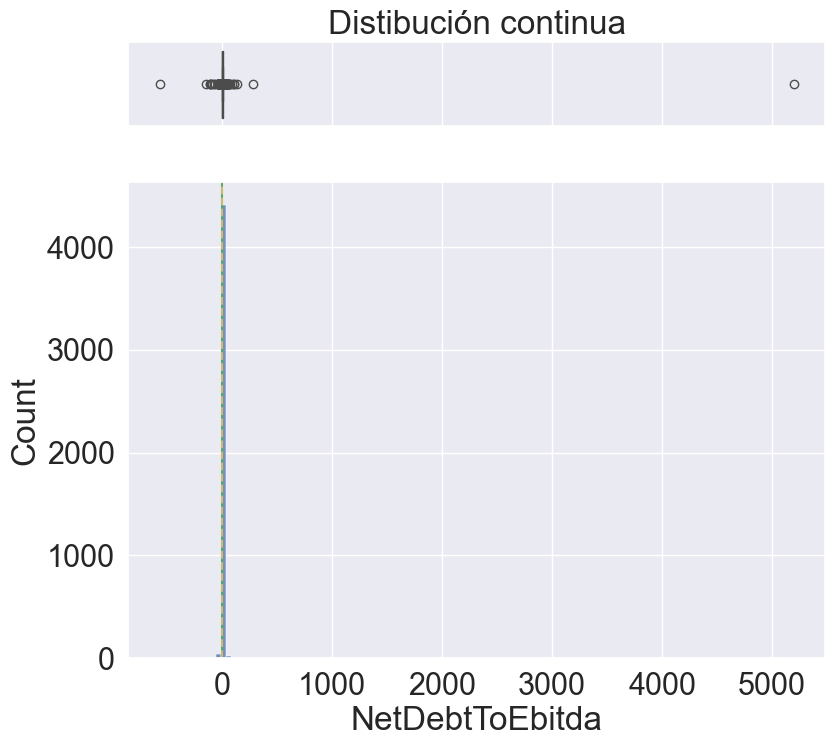

In [20]:
# Graficar
columna_a_graficar = 'NetDebtToEbitda' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [21]:
# Transformaciones logarítmicas

columnas_a_transformar = [ 
    'CurrentRatio',
    'RelativeAssets',
    'RelativeRevenue'
    ]
for columna in columnas_a_transformar:
    df_transformed[columna] = df_transformed[columna].fillna(0)
    df_transformed[f'{columna}_log'] = np.log1p(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

NetDebtToEbitda           64.531148
FcfToEbitda               40.561187
Dividends                 35.494197
CapExToRevenue            29.341672
PriceToBook               14.917165
MarketCap                 13.393551
Open                      13.368548
EnterpriseValue           13.264977
Close                     12.050044
CurrentDebt               11.999995
NetIncome_TTM             11.280549
OperatingCashFlow_TTM      9.715676
EBITDA_TTM                 9.413978
OperatingIncome_TTM        9.345105
RelativeAssets_log         8.733933
DebtToEquity               7.799918
BasicAverageShares_TTM     7.627500
FreeCashFlow_TTM           7.603894
Revenue_QoQ                7.340280
GrossProfit_TTM            7.266708
StockholdersEquity         7.028306
RelativeRevenue_log        6.674497
ReturnOnEquity             5.929547
CurrentLiabilities         5.778911
TotalRevenue_TTM           5.661168
CashAndCashEquivalents     4.986506
CurrentAssets              4.941057
TotalAssets                4

In [22]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = cols_monetarias + [
    # Variables de precio (posibles label)
    'Close',
    'Open',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    # Otras
    'Date', 
    'Ticker',
    'Dividends'        
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [23]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

OperatingMargins
ProfitMargins
ReturnOnEquity
ReturnOnAssets
DebtToEquity
Revenue_YoY
Revenue_QoQ
Ebitda_YoY
Ebitda_QoQ
Fcf_YoY
Fcf_QoQ
CapEx_YoY
CapEx_QoQ
NetDebtToEbitda
FcfToEbitda
CapExToRevenue
QuarterlyReturn
QuarterlyVariance
MarketCovariance
YearsSinceAdded
CurrentRatio_log
RelativeAssets_log
RelativeRevenue_log


In [24]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

RelativeAssets_log     1.776952
CapExToRevenue         1.739542
RelativeRevenue_log    1.690494
Ebitda_YoY             1.456137
Revenue_YoY            1.333384
Revenue_QoQ            1.287621
YearsSinceAdded        1.191019
Fcf_YoY                1.080008
Ebitda_QoQ             1.016564
CurrentRatio_log       1.008240
Fcf_QoQ                0.689454
ReturnOnAssets         0.623898
NetDebtToEbitda        0.529011
OperatingMargins       0.381675
QuarterlyReturn        0.294844
ProfitMargins          0.196803
DebtToEquity           0.048111
QuarterlyVariance     -0.005601
ReturnOnEquity        -0.067395
CapEx_YoY             -0.163847
FcfToEbitda           -0.184365
MarketCovariance      -0.510610
CapEx_QoQ             -0.982644
dtype: float64

Cont


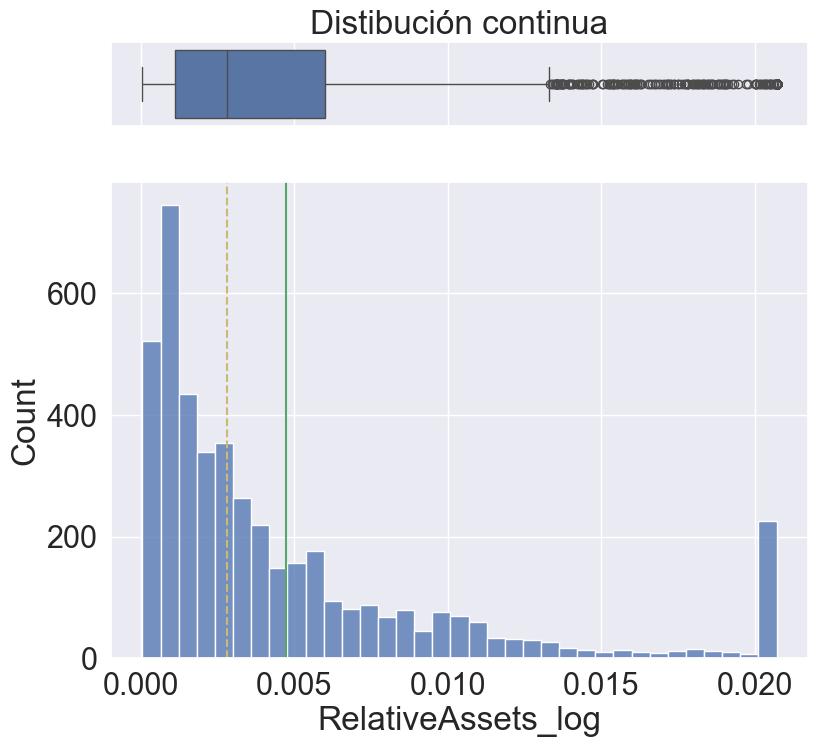

In [25]:
# Visualizar cambios
columna_a_graficar = 'RelativeAssets_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [26]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
OperatingMargins,4489.0,0.192780,0.154869,-0.436953,0.099607,0.172858,0.270234,0.783406
ProfitMargins,4489.0,0.127847,0.147664,-0.404726,0.047629,0.113818,0.197882,0.660730
ReturnOnEquity,4489.0,0.150611,0.299065,-0.590894,0.058192,0.131731,0.274448,0.946867
ReturnOnAssets,4489.0,0.065418,0.066989,-0.165774,0.028796,0.053699,0.090220,0.289382
DebtToEquity,4489.0,0.884129,1.503926,-2.702879,0.364786,0.714789,1.384881,4.487779
Revenue_YoY,4489.0,1.061815,0.974255,-0.614272,0.192445,1.015499,1.928062,7.251315
Revenue_QoQ,4489.0,0.298538,0.455110,-0.824727,0.034205,0.076219,0.371529,1.452501
Ebitda_YoY,4489.0,1.153402,1.136082,-4.978069,0.287251,0.901467,1.963964,7.027704
Ebitda_QoQ,4489.0,0.338255,0.545432,-1.817566,0.028975,0.107196,0.521287,2.037829
Fcf_YoY,4489.0,1.020789,1.322363,-4.496226,0.187176,0.872881,1.746499,6.432121


## Concatenación final de columnas

In [27]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4489 entries, 0 to 4488
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  4489 non-null   float64       
 1   CurrentDebt             4489 non-null   float64       
 2   LongTermDebt            4489 non-null   float64       
 3   TotalDebt               4489 non-null   float64       
 4   StockholdersEquity      4489 non-null   float64       
 5   TotalAssets             4489 non-null   float64       
 6   CurrentAssets           4489 non-null   float64       
 7   CurrentLiabilities      4489 non-null   float64       
 8   OperatingCashFlow_TTM   4489 non-null   float64       
 9   InvestingCashFlow_TTM   4489 non-null   float64       
 10  FinancingCashFlow_TTM   4489 non-null   float64       
 11  FreeCashFlow_TTM        4489 non-null   float64       
 12  CapitalExpenditure_TTM  4489 non-null   float64 

In [28]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")